# Ejercicio 7 — Indicadores y tablero Metabase

Trabajo individual. Trece preguntas respaldadas por SQL, poblaciones explícitas y visualizaciones nativas de Metabase. Año inicial 2026; el tablero permite seleccionar 2024 y distinguir la cobertura parcial de 2026.

La fuente es la tabla materializada `viajes_duckdb`, abierta en modo de solo lectura. Este notebook calcula resultados de referencia; el script de Metabase instala las tarjetas y guarda evidencia de sus consultas y disposición. Las credenciales y sesiones permanecen fuera de Git.

In [1]:
from pathlib import Path
import os, sys, json
import pandas as pd
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'scripts'/'build_indicators.py').exists())
os.chdir(ROOT)
sys.path.insert(0,str(ROOT/'scripts'))
from build_indicators import build
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',50)
frames=build(year=2026,taxi='all')

Indicador DuckDB: 01_viajes 1 filas


Indicador DuckDB: 02_retencion 1 filas


Indicador DuckDB: 03_distancia 1 filas


Indicador DuckDB: 04_total 1 filas


Indicador DuckDB: 05_mensual 16 filas


...

Indicador DuckDB: 09_distribucion 12 filas


Indicador DuckDB: 10_pago 11 filas


Indicador DuckDB: 11_propinas 2 filas


Indicador DuckDB: 12_negativos 11 filas


Indicador DuckDB: 13_cobertura 2 filas


## Poblaciones y cobertura

Original: todas las filas del año/tipo seleccionado. Temporal: recogida dentro del mes del archivo. Mediciones: además, distancia (0,100] millas, duración (0,1440] minutos, total positivo y tarifa no negativa. Se conservan pagos y pasajeros ausentes. Propinas: solo tarjeta con tarifa positiva y propina no negativa.

Los umbrales son decisiones exploratorias, no normas oficiales. Los índices relativos evitan que el volumen de amarillos oculte el perfil de verdes. Los resultados no permiten inferir causalidad, extrapolar el año incompleto o tratar propinas en efectivo como cero.

## 01_viajes: Viajes con fechas válidas

**Pregunta:** ¿Cuántos viajes hay en la selección?

**Justificación:** Cuantifica el volumen observado sin confundir los meses no publicados con cero viajes.

**Población:** temporal. **Unidad:** viajes.

**Visualización Metabase:** scalar.

In [2]:
print((ROOT/'sql/indicadores/01_viajes.sql').read_text())
display(frames['01_viajes'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT count(*) AS viajes FROM temporal;



,viajes
0,30040225


## 02_retencion: Cobertura de mediciones (%)

**Pregunta:** ¿Qué porcentaje conserva el análisis de mediciones?

**Justificación:** Expone el efecto del filtrado y su denominador.

**Población:** temporal y mediciones. **Unidad:** %.

**Visualización Metabase:** scalar.

In [3]:
print((ROOT/'sql/indicadores/02_retencion.sql').read_text())
display(frames['02_retencion'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT 100.0*count_if(trip_distance>0 AND trip_distance<=100 AND duracion_minutos>0 AND duracion_minutos<=1440 AND total_amount>0 AND fare_amount>=0)/nullif(count(*),0) AS porcentaje FROM temporal;



,porcentaje
0,95.085083


## 03_distancia: Distancia mediana (millas)

**Pregunta:** ¿Cuál es la distancia típica?

**Justificación:** La mediana reduce la influencia de extremos; se declara la población filtrada.

**Población:** mediciones. **Unidad:** millas.

**Visualización Metabase:** scalar.

In [4]:
print((ROOT/'sql/indicadores/03_distancia.sql').read_text())
display(frames['03_distancia'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT approx_quantile(trip_distance,0.5) AS mediana_millas FROM mediciones;



,mediana_millas
0,1.937411


## 04_total: Total mediano (USD)

**Pregunta:** ¿Cuánto se paga típicamente?

**Justificación:** El total incluye conceptos adicionales a la tarifa base; no equivale a precio por milla.

**Población:** mediciones. **Unidad:** USD.

**Visualización Metabase:** scalar.

In [5]:
print((ROOT/'sql/indicadores/04_total.sql').read_text())
display(frames['04_total'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT approx_quantile(total_amount,0.5) AS mediana_usd FROM mediciones;



,mediana_usd
0,23.555628


## 05_mensual: Evolución mensual · índice diario

**Pregunta:** ¿Cómo cambia la demanda diaria por mes y tipo?

**Justificación:** Normaliza los días de cada mes y muestra el cambio relativo para comparar tipos de distinto volumen.

**Población:** temporal. **Unidad:** índice: primer mes = 100.

**Visualización Metabase:** line.

In [6]:
print((ROOT/'sql/indicadores/05_mensual.sql').read_text())
display(frames['05_mensual'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
 , mensual AS (
 SELECT tipo_taxi,mes_archivo AS mes,count(*) AS viajes,
 count(*)::DOUBLE/day(last_day(mes_archivo)) AS viajes_por_dia
 FROM temporal GROUP BY tipo_taxi,mes_archivo
 )
 SELECT mes,tipo_taxi,viajes,viajes_por_dia,
 100.0*viajes_por_dia/first_value(viajes_por_dia) OVER(PARTITION BY tipo_taxi ORDER BY mes) AS indice_base100
 FROM mensual ORDER BY mes,tipo_taxi

,mes,tipo_taxi,viajes,viajes_por_dia,indice_base100
0,2026-01-01,green,40250,1298.387097,100.000000
1,2026-01-01,yellow,3724882,120157.483871,100.000000
2,2026-02-01,green,37362,1334.357143,102.770364
3,2026-02-01,yellow,3399850,121423.214286,101.053393
4,2026-03-01,green,44199,1425.774194,109.811180
5,2026-03-01,yellow,3952432,127497.806452,106.108918
6,2026-04-01,green,44235,1474.500000,113.563975
7,2026-04-01,yellow,3831228,127707.600000,106.283517
8,2026-05-01,green,44911,1448.741935,111.580124
9,2026-05-01,yellow,4090822,131962.000000,109.824204


## 06_hora: Perfil horario (%)

**Pregunta:** ¿En qué horas se concentran los viajes?

**Justificación:** Usa proporciones dentro de cada tipo para que amarillos no oculten a verdes.

**Población:** temporal. **Unidad:** % dentro del tipo.

**Visualización Metabase:** line.

In [7]:
print((ROOT/'sql/indicadores/06_hora.sql').read_text())
display(frames['06_hora'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT hour(recogida) AS hora,tipo_taxi,count(*) AS viajes,
 100.0*count(*)/sum(count(*)) OVER(PARTITION BY tipo_taxi) AS porcentaje
 FROM temporal GROUP BY hora,tipo_taxi ORDER BY hora,tipo_taxi;



,hora,tipo_taxi,viajes,porcentaje
0,0,green,5287,1.568768
1,0,yellow,933588,3.143054
2,1,green,3370,0.999953
3,1,yellow,621770,2.093276
4,2,green,2459,0.729639
5,2,yellow,415196,1.397815
6,3,green,2041,0.605609
7,3,yellow,298876,1.006208
8,4,green,2057,0.610357
9,4,yellow,245038,0.824955


## 07_semana: Demanda semanal · índice diario

**Pregunta:** ¿Qué días tienen más demanda promedio?

**Justificación:** Divide por las ocurrencias de cada día en los meses disponibles.

**Población:** temporal. **Unidad:** índice respecto al promedio diario.

**Visualización Metabase:** bar.

In [8]:
print((ROOT/'sql/indicadores/07_semana.sql').read_text())
display(frames['07_semana'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
 , meses AS (SELECT DISTINCT tipo_taxi,mes_archivo FROM base),
 calendario AS (SELECT tipo_taxi,isodow(dia) AS dia FROM meses,
 LATERAL generate_series(mes_archivo,last_day(mes_archivo),INTERVAL 1 DAY) AS fechas(dia)),
 dias AS (SELECT tipo_taxi,dia,count(*) AS dias_calendario FROM calendario GROUP BY tipo_taxi,dia),
 conteos AS (SELECT tipo_taxi,isodow(recogida) AS dia,cou

,dia_semana,tipo_taxi,viajes_por_dia,indice_base100
0,Lunes,green,1368.914286,98.703377
1,Lunes,yellow,101499.485714,83.036062
2,Martes,green,1493.941176,107.718241
3,Martes,yellow,119611.882353,97.853695
4,Miércoles,green,1549.382353,111.715738
5,Miércoles,yellow,127623.823529,104.408211
6,Jueves,green,1590.257143,114.662949
7,Jueves,yellow,135471.257143,110.828145
8,Viernes,green,1447.742857,104.387185
9,Viernes,yellow,128829.228571,105.394345


## 08_duracion: Duración mediana por taxi (min)

**Pregunta:** ¿Cómo difiere la duración típica entre tipos?

**Justificación:** Compara la misma población de mediciones y usa una unidad única.

**Población:** mediciones. **Unidad:** minutos.

**Visualización Metabase:** bar.

In [9]:
print((ROOT/'sql/indicadores/08_duracion.sql').read_text())
display(frames['08_duracion'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT tipo_taxi,count(*) AS viajes,approx_quantile(duracion_minutos,0.5) AS mediana_minutos FROM mediciones GROUP BY tipo_taxi ORDER BY tipo_taxi;



,tipo_taxi,viajes,mediana_minutos
0,green,323668,13.342477
1,yellow,28240105,14.122950


## 09_distribucion: Distribución de distancia (%)

**Pregunta:** ¿Predominan los viajes cortos?

**Justificación:** Muestra la forma de la distribución en intervalos explícitos.

**Población:** mediciones. **Unidad:** % dentro del tipo.

**Visualización Metabase:** bar.

In [10]:
print((ROOT/'sql/indicadores/09_distribucion.sql').read_text())
display(frames['09_distribucion'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
 , grupos AS (SELECT tipo_taxi,CASE WHEN trip_distance<=1 THEN 1 WHEN trip_distance<=2 THEN 2
 WHEN trip_distance<=5 THEN 3 WHEN trip_distance<=10 THEN 4 WHEN trip_distance<=20 THEN 5 ELSE 6 END AS orden
 FROM mediciones)
 SELECT CASE orden WHEN 1 THEN '(0,1] mi' WHEN 2 THEN '(1,2] mi' WHEN 3 THEN '(2,5] mi'
 WHEN 4 THEN '(5,10] mi' WHEN 5 THEN '(10,20] mi' ELSE '(20,100] m

,intervalo,tipo_taxi,viajes,porcentaje
0,"(0,1] mi",green,46328,14.313432
1,"(0,1] mi",yellow,6201646,21.960421
2,"(1,2] mi",green,104953,32.426128
3,"(1,2] mi",yellow,8420162,29.816327
4,"(2,5] mi",green,113576,35.090278
5,"(2,5] mi",yellow,8093288,28.658845
6,"(5,10] mi",green,40157,12.406849
7,"(5,10] mi",yellow,3369353,11.931092
8,"(10,20] mi",green,16891,5.218619
9,"(10,20] mi",yellow,1916945,6.788024


## 10_pago: Formas de pago (%)

**Pregunta:** ¿Qué modalidades de pago predominan?

**Justificación:** Conserva Flex Fare y los pagos sin dato sin reasignarlos a efectivo o tarjeta.

**Población:** temporal. **Unidad:** % dentro del tipo.

**Visualización Metabase:** bar.

In [11]:
print((ROOT/'sql/indicadores/10_pago.sql').read_text())
display(frames['10_pago'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT CASE payment_type WHEN 0 THEN 'Flex Fare' WHEN 1 THEN 'Tarjeta' WHEN 2 THEN 'Efectivo'
 WHEN 3 THEN 'Sin cargo' WHEN 4 THEN 'Disputa' WHEN 5 THEN 'Desconocido' WHEN 6 THEN 'Anulado' ELSE 'Sin dato' END AS forma_pago,
 tipo_taxi,count(*) AS viajes,100.0*count(*)/sum(count(*)) OVER(PARTITION BY tipo_taxi) AS porcentaje
 FROM temporal GROUP BY tipo_taxi,payment_type ORD

,forma_pago,tipo_taxi,viajes,porcentaje
0,Flex Fare,yellow,7716688,25.979307
1,Tarjeta,green,219903,65.250018
2,Tarjeta,yellow,18940892,63.767157
3,Efectivo,green,65902,19.554561
4,Efectivo,yellow,2708007,9.116884
5,Sin cargo,green,1686,0.500273
6,Sin cargo,yellow,98132,0.330375
7,Disputa,green,750,0.222541
8,Disputa,yellow,239488,0.806270
9,Desconocido,yellow,2,0.000007


## 11_propinas: Propina / tarifa · mediana (%)

**Pregunta:** ¿Cómo difieren las propinas registradas en tarjeta?

**Justificación:** Las propinas en efectivo no se registran; el denominador es fare_amount, no el total.

**Población:** mediciones, tarjeta, tarifa positiva y propina no negativa. **Unidad:** % de tarifa base.

**Visualización Metabase:** bar.

In [12]:
print((ROOT/'sql/indicadores/11_propinas.sql').read_text())
display(frames['11_propinas'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT tipo_taxi,count(*) AS viajes_elegibles,
 100.0*count_if(tip_amount=0)/count(*) AS porcentaje_sin_propina,
 approx_quantile(100.0*tip_amount/fare_amount,0.5) AS tasa_mediana
 FROM mediciones WHERE payment_type=1 AND fare_amount>0 AND tip_amount>=0 GROUP BY tipo_taxi ORDER BY tipo_taxi;



,tipo_taxi,viajes_elegibles,porcentaje_sin_propina,tasa_mediana
0,green,212456,8.664382,23.580045
1,yellow,18460906,8.882294,26.412395


## 12_negativos: Totales negativos por pago (%)

**Pregunta:** ¿Dónde aparecen importes negativos?

**Justificación:** Mantiene las anomalías y sus denominadores; no atribuye automáticamente causas.

**Población:** temporal. **Unidad:** % negativo en categoría.

**Visualización Metabase:** bar.

In [13]:
print((ROOT/'sql/indicadores/12_negativos.sql').read_text())
display(frames['12_negativos'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT CASE payment_type WHEN 0 THEN 'Flex Fare' WHEN 1 THEN 'Tarjeta' WHEN 2 THEN 'Efectivo'
 WHEN 3 THEN 'Sin cargo' WHEN 4 THEN 'Disputa' WHEN 5 THEN 'Desconocido' WHEN 6 THEN 'Anulado' ELSE 'Sin dato' END AS forma_pago,
 tipo_taxi,count(*) AS viajes_categoria,count_if(total_amount<0) AS negativos,
 100.0*count_if(total_amount<0)/count(*) AS porcentaje_negativo
 FROM tem

,forma_pago,tipo_taxi,viajes_categoria,negativos,porcentaje_negativo
0,Flex Fare,yellow,7716688,94.0,0.001218
1,Tarjeta,green,219903,137.0,0.062300
2,Tarjeta,yellow,18940892,3511.0,0.018537
3,Efectivo,green,65902,43.0,0.065248
4,Efectivo,yellow,2708007,39646.0,1.464029
5,Sin cargo,green,1686,563.0,33.392645
6,Sin cargo,yellow,98132,17727.0,18.064444
7,Disputa,green,750,279.0,37.200000
8,Disputa,yellow,239488,100854.0,42.112340
9,Desconocido,yellow,2,0.0,0.000000


## 13_cobertura: Cobertura de archivos y años

**Pregunta:** ¿Qué meses y años respaldan la selección?

**Justificación:** Evita comparar un año completo con otro parcial.

**Población:** original. **Unidad:** archivos y registros.

**Visualización Metabase:** table.

In [14]:
print((ROOT/'sql/indicadores/13_cobertura.sql').read_text())
display(frames['13_cobertura'])

-- Parámetros opcionales de Metabase: año de archivo y tipo yellow/green.
WITH base AS NOT MATERIALIZED (
 SELECT *, date_diff('second', recogida, llegada)/60.0 AS duracion_minutos
 FROM viajes_duckdb WHERE TRUE
 [[AND year(mes_archivo) = {{anio}}]]
 [[AND tipo_taxi = {{tipo_taxi}}]]
), temporal AS NOT MATERIALIZED (
 SELECT * FROM base WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
), mediciones AS NOT MATERIALIZED (
 SELECT * FROM temporal WHERE trip_distance > 0 AND trip_distance <= 100
 AND duracion_minutos > 0 AND duracion_minutos <= 1440
 AND total_amount > 0 AND fare_amount >= 0
)
SELECT year(mes_archivo) AS anio,tipo_taxi,count(DISTINCT archivo) AS archivos,
 count(DISTINCT mes_archivo) AS meses,count(*) AS registros,
 min(mes_archivo) AS primer_mes,max(mes_archivo) AS ultimo_mes
 FROM base GROUP BY anio,tipo_taxi ORDER BY anio,tipo_taxi;



,anio,tipo_taxi,archivos,meses,registros,primer_mes,ultimo_mes
0,2026,green,8,8,337114,2026-01-01,2026-08-01
1,2026,yellow,8,8,29703355,2026-01-01,2026-08-01


## Tablero y evidencia

La configuración está en `docs/tablero/indicadores.json`. La instalación conecta DuckDB en read_only, crea/actualiza el tablero y sus filtros, ejecuta cada consulta y guarda evidencia sin secretos. Primero complete la cuenta de Metabase, luego inicie sesión en Terminal con `scripts/metabase_dashboard.py --login` y ejecute el mismo script sin esa opción.

Las consultas nativas de Metabase están guardadas en SQL; `[[...]]` y `{{...}}` son bloques y parámetros del motor de plantillas, convertidos a literales seguros para la referencia DuckDB de este notebook. El año de archivo se declara explícitamente.

Tablero: [http://localhost:3000/dashboard/2](http://localhost:3000/dashboard/2)

Indicadores verificados: 13


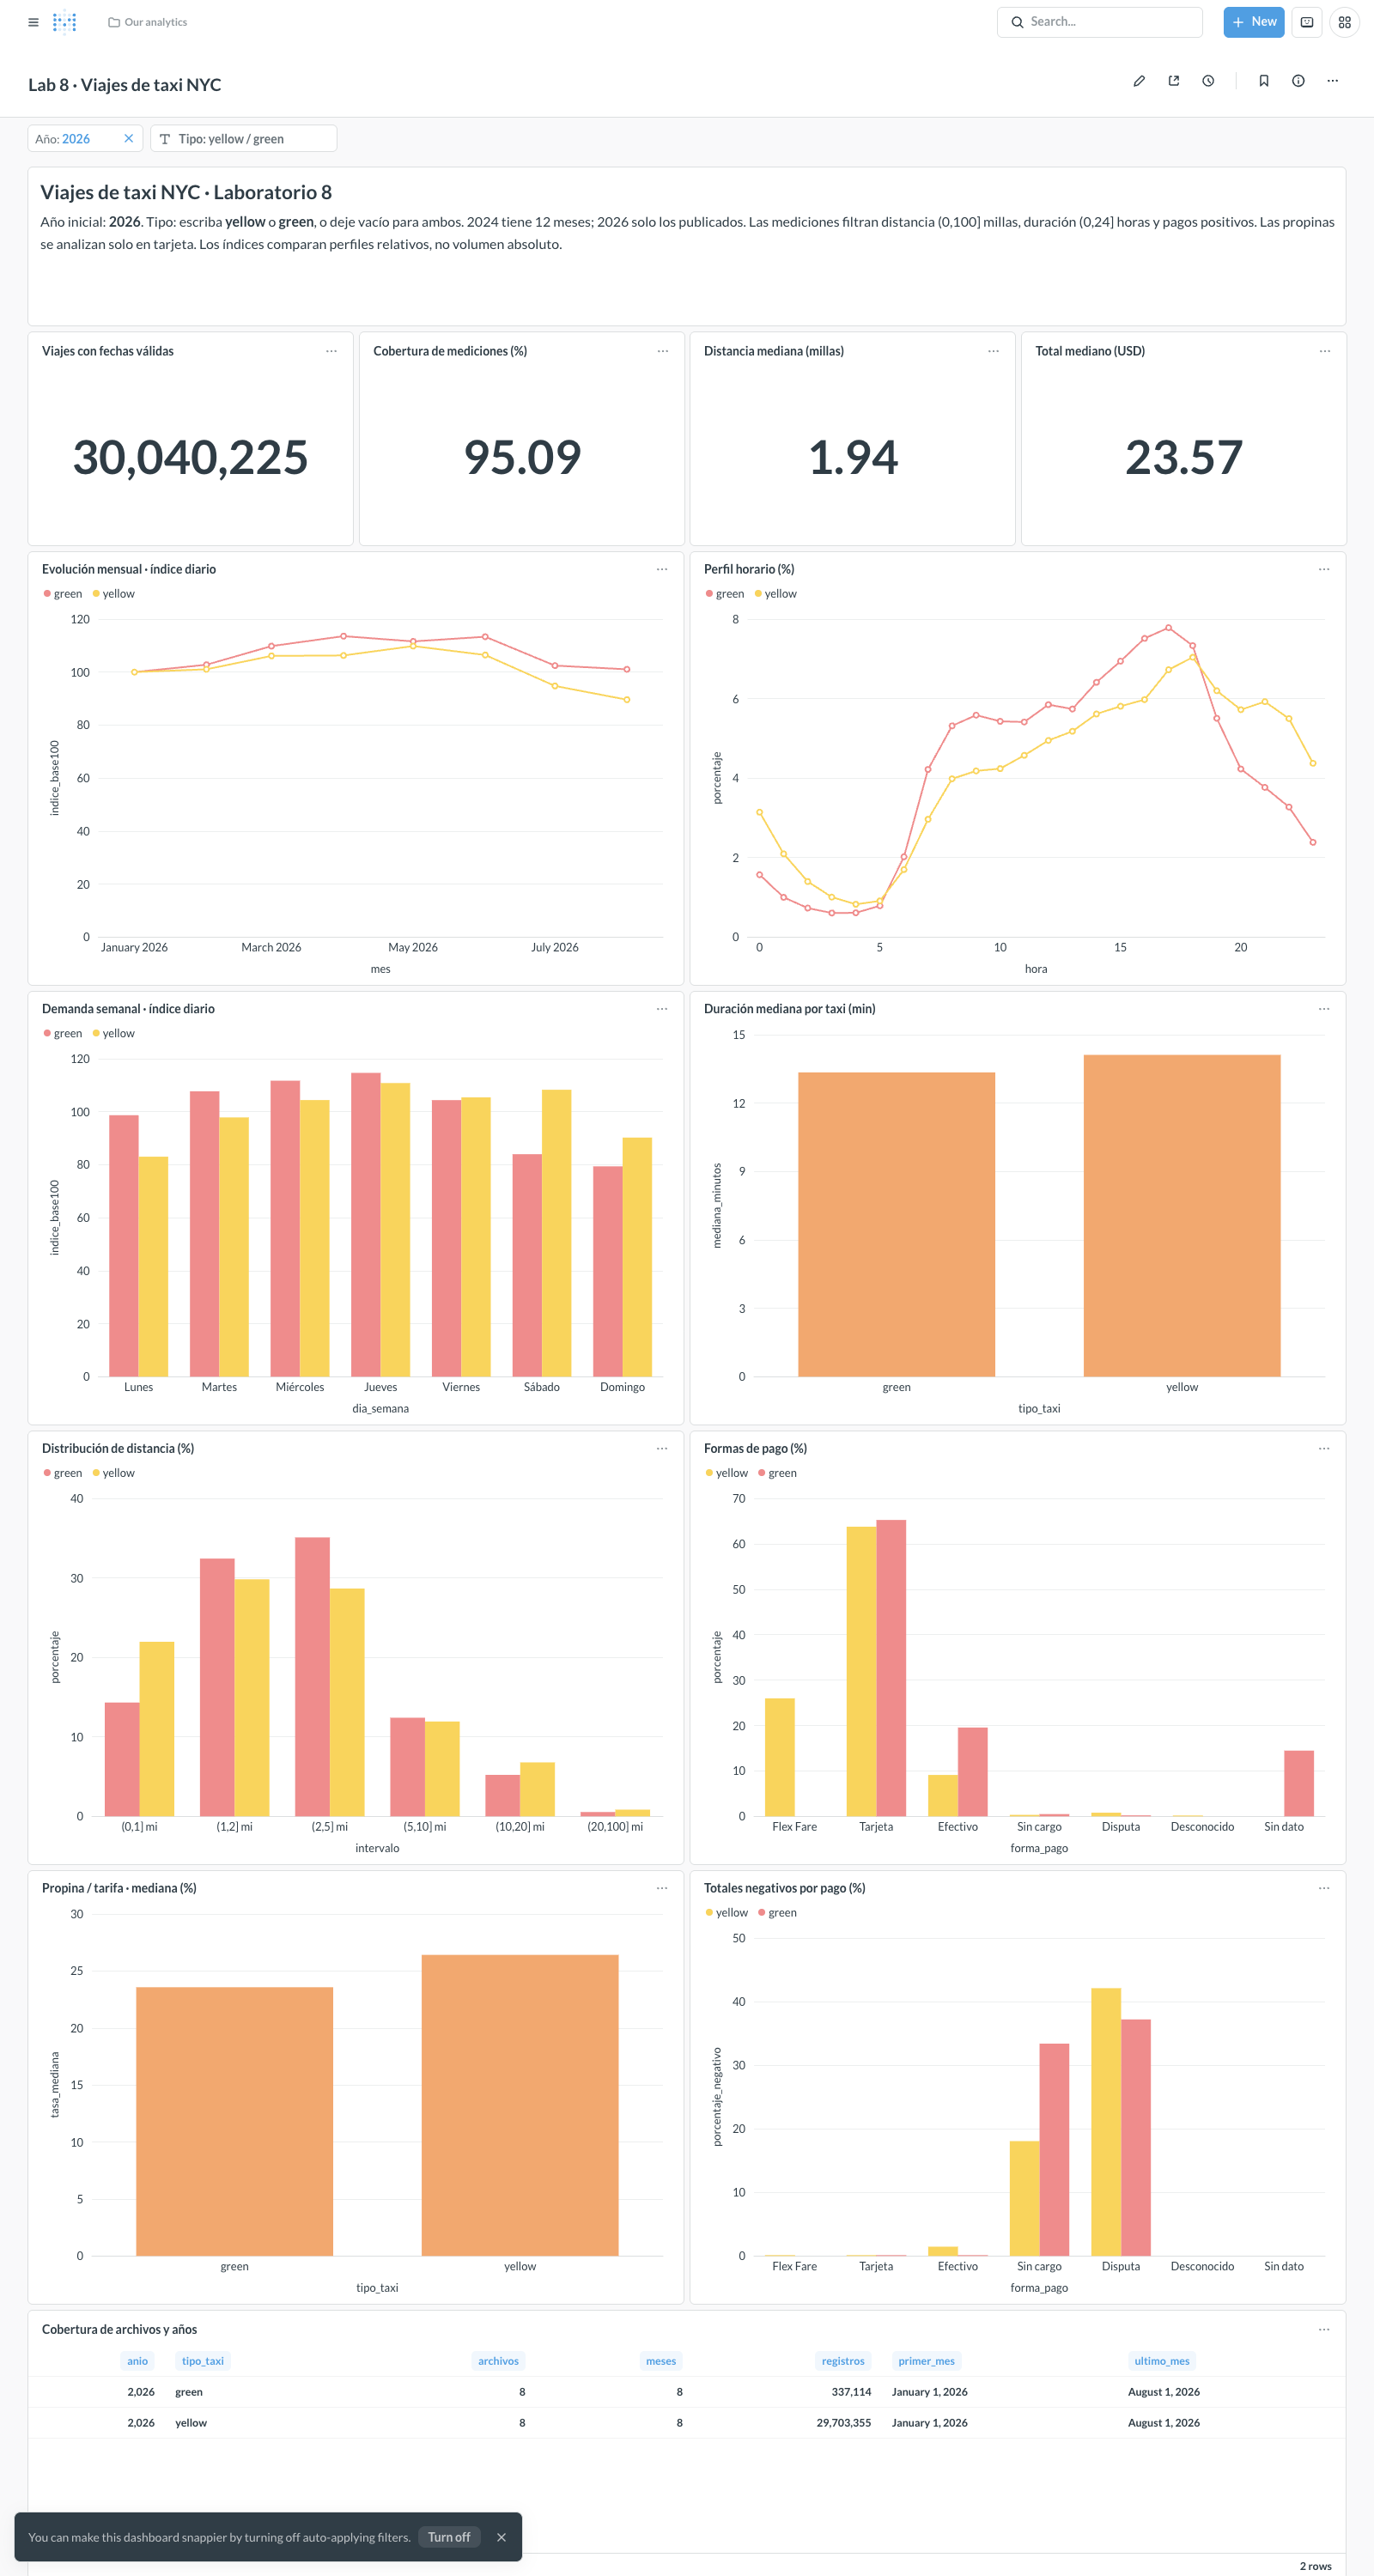

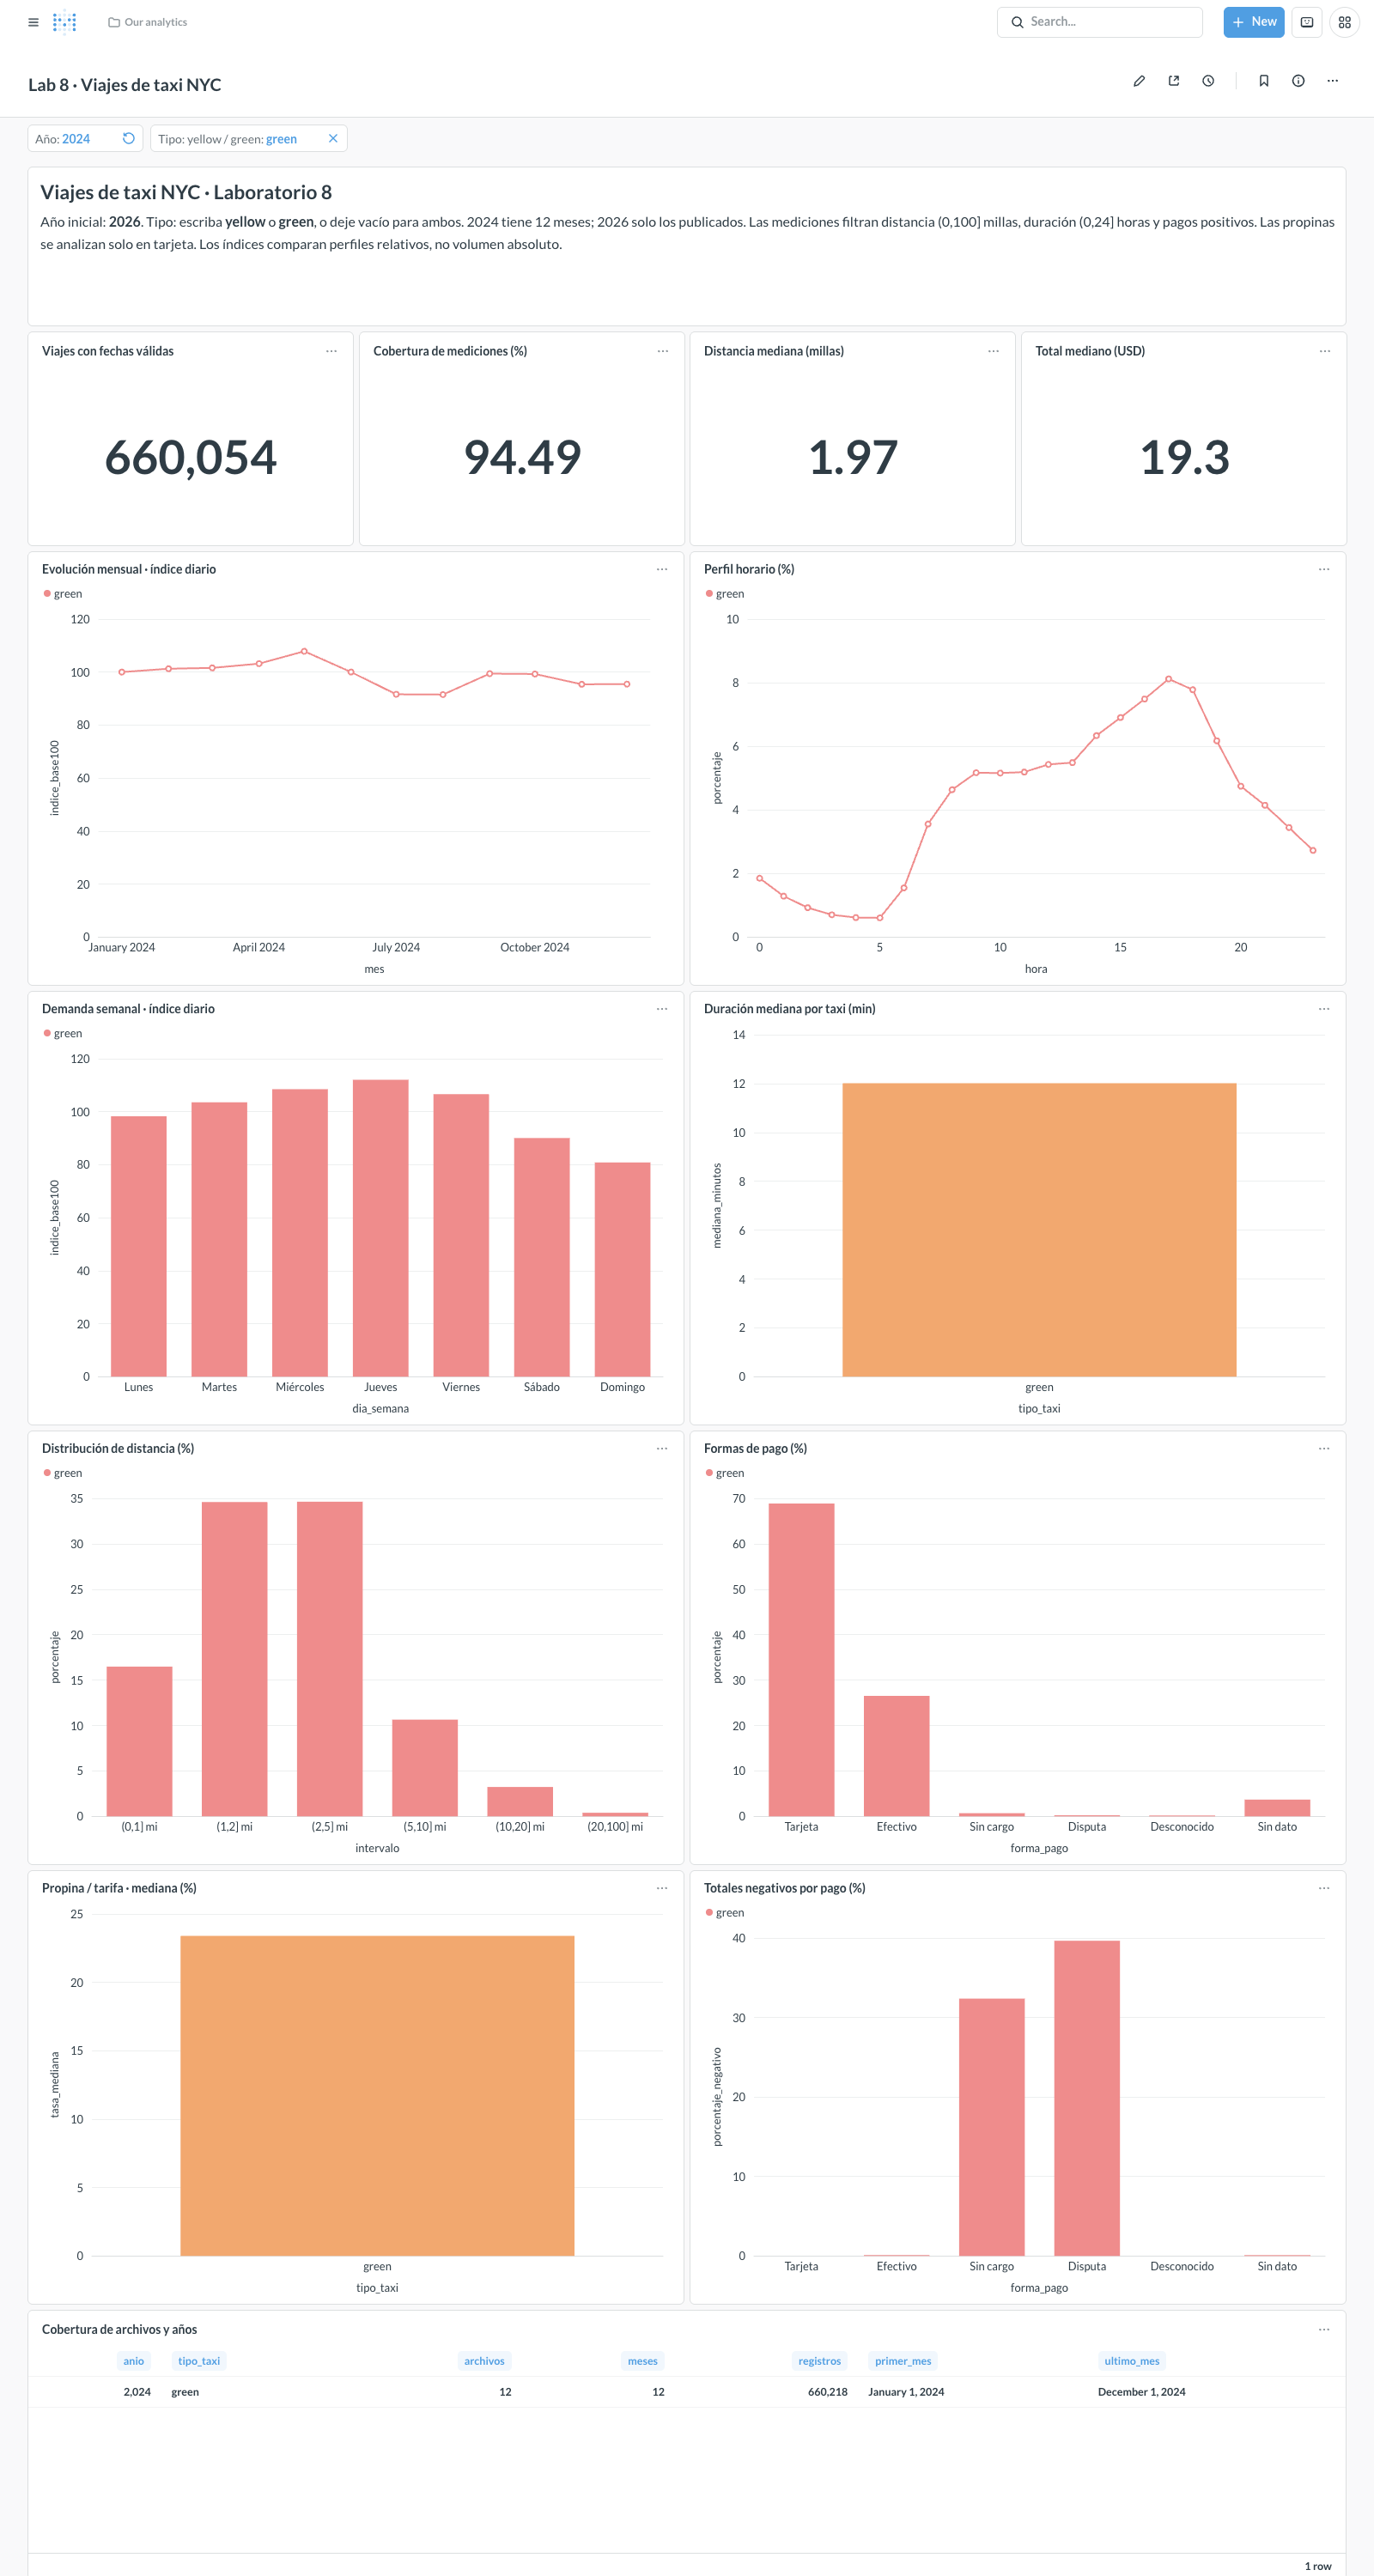

In [15]:
evidence_path=ROOT/'docs'/'tablero'/'metabase_evidencia.json'
if evidence_path.exists():
    evidence=json.loads(evidence_path.read_text())
    display(Markdown(f"Tablero: [{evidence['url']}]({evidence['url']})"))
    print('Indicadores verificados:',evidence['indicadores'])
else:
    print('Pendiente de instalación autenticada en Metabase; los resultados de referencia están calculados.')
from IPython.display import Image
for filename in ("captura_metabase.png", "captura_2024_green.png"):
    capture=ROOT/"docs"/"tablero"/filename
    if capture.exists(): display(Image(filename=str(capture)))


## Interpretación

Los picos horarios y las formas de pago se comparan como porcentajes dentro de cada tipo. El costo típico utiliza la mediana de total_amount y no es una tarifa por milla. Las medianas son aproximadas. La proporción de mediciones retenidas declara el costo de excluir alertas; el tablero de importes negativos conserva esas filas para no ocultar el problema.

Las propinas se analizan sobre fare_amount y solo para tarjeta, conforme a los diccionarios [amarillo](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) y [verde](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf). Las interpretaciones cuantitativas están en `docs/ejercicio_7_indicadores.md`.